In [1]:
from langgraph.graph import MessagesState
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
model = ChatOllama(model="phi3", temperature=0)

In [3]:
class ChatState(MessagesState):
    summary: str

In [4]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [5]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [6]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [7]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [8]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

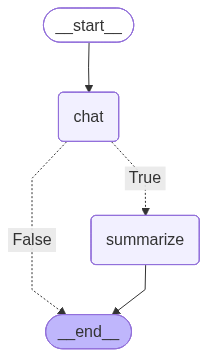

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [11]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [12]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='31367bd7-e938-4b2a-96ed-dab3981dd7b4')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental theory in phy


In [13]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='31367bd7-e938-4b2a-96ed-dab3981dd7b4'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes nature at the smallest scales of energy levels of atoms and subatomic particles. It provides a mathematical framework for understanding how these tiny constituents of matter behave under various conditions. Quantum mechanics departs from classical mechanics primarily at the quantum realm of atomic and subatomic length scales, revealing phenomena such as quantization of physical properties like energy and momentum; wave-particle duality where particles exhibit both wave-like and particle-like characteristics; superposition allowing a system to be in multiple states simultaneously until it is measured or observed; entanglement which describes the interconnectedness between quantum systems regardless of distance.\n\nThe theory has led to numerou

In [14]:
run_turn('What are some of Einstien"s fampus work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='31367bd7-e938-4b2a-96ed-dab3981dd7b4'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes nature at the smallest scales of energy levels of atoms and subatomic particles. It provides a mathematical framework for understanding how these tiny constituents of matter behave under various conditions. Quantum mechanics departs from classical mechanics primarily at the quantum realm of atomic and subatomic length scales, revealing phenomena such as quantization of physical properties like energy and momentum; wave-particle duality where particles exhibit both wave-like and particle-like characteristics; superposition allowing a system to be in multiple states simultaneously until it is measured or observed; entanglement which describes the interconnectedness between quantum systems regardless of distance.\n\nThe theory has led to numerou

In [ ]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='31367bd7-e938-4b2a-96ed-dab3981dd7b4'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes nature at the smallest scales of energy levels of atoms and subatomic particles. It provides a mathematical framework for understanding how these tiny constituents of matter behave under various conditions. Quantum mechanics departs from classical mechanics primarily at the quantum realm of atomic and subatomic length scales, revealing phenomena such as quantization of physical properties like energy and momentum; wave-particle duality where particles exhibit both wave-like and particle-like characteristics; superposition allowing a system to be in multiple states simultaneously until it is measured or observed; entanglement which describes the interconnectedness between quantum systems regardless of distance.\n\nThe theory has led to numerou